In [ ]:
#%conda install pytorch torchvision torchaudio pytorch-cuda=12.4 -c pytorch -c nvidia -y
#%conda install -c conda-forge gymnasium numpy pytesseract stable-baselines3 mss opencv matplotlib -y
#%conda install -c conda-forge pydirectinput -y

In [1]:
%pip install pynput
#%pip install pillow==8.0.0
from pynput import mouse, keyboard

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sqlite3

#mss used for screenshotting 
from mss import mss

#Gym used Environment components
import gymnasium as gym
from gymnasium import Env
from gymnasium import spaces

print("all good")

#Imports
#Pytorch used for the neural nets
import torch
import torchvision

#NumPy used for operations (Transformational framework)
import numpy as np

#OpenCV used for frame processing
import cv2

#Matplotlib to visualize captured frames
from matplotlib import pyplot as plt

#time for pauses
import time
from collections import deque



all good


In [3]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\envs\new_env\python.exe


In [4]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("PyTorch CUDA Version:", torch.version.cuda)

CUDA Available: True
PyTorch CUDA Version: 11.8


In [5]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 4070 Laptop GPU


(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)


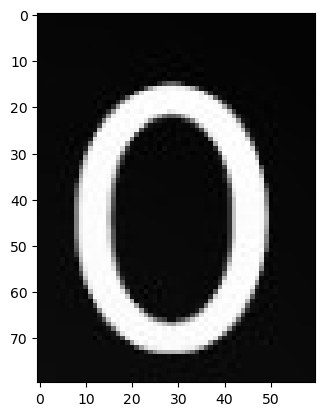

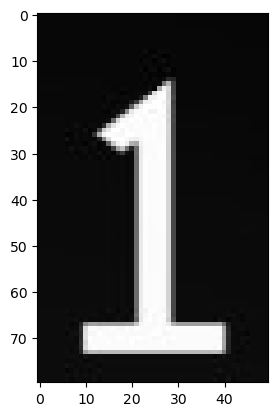

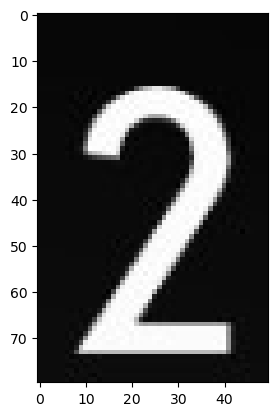

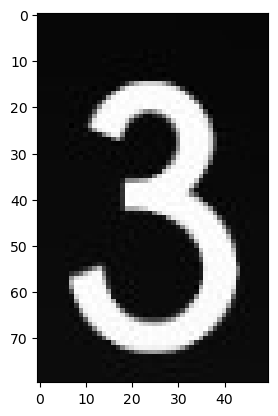

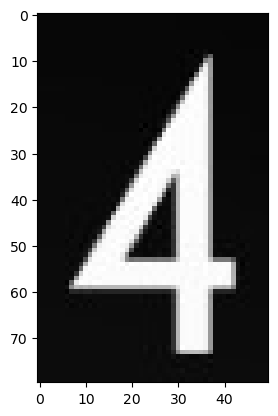

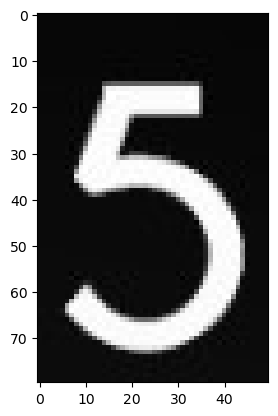

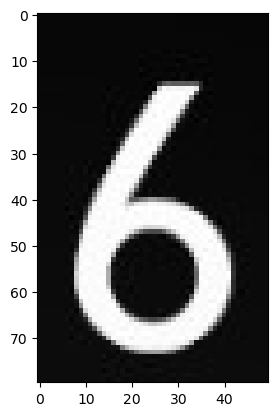

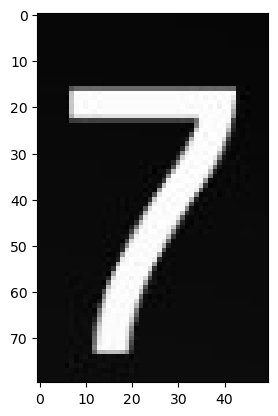

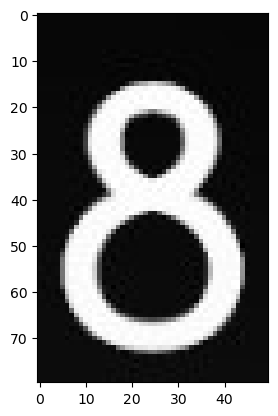

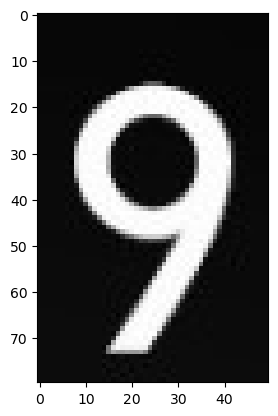

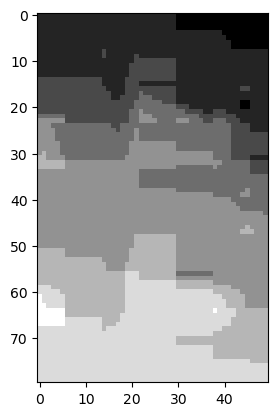

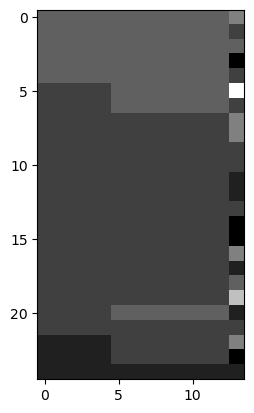

(25, 14)


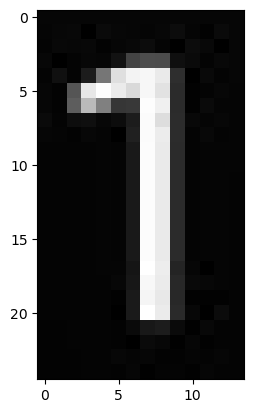

(25, 14)
(25, 14)
(25, 14)
(25, 14)
(25, 14)
(25, 14)
(25, 14)
(25, 14)
(25, 14)
(25, 14)


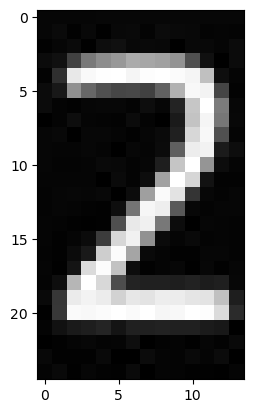

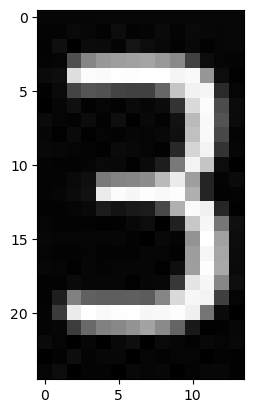

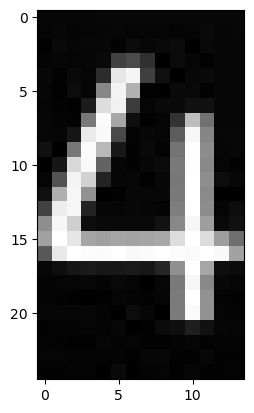

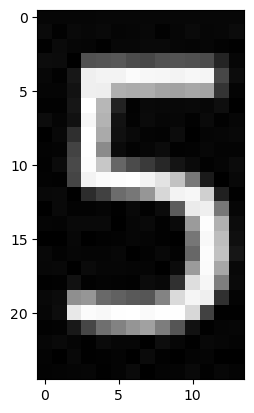

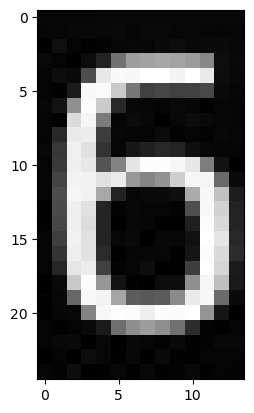

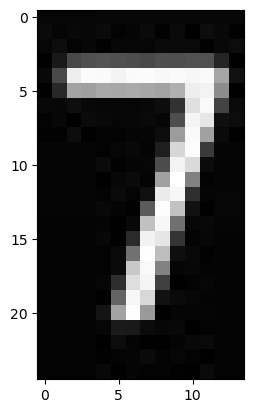

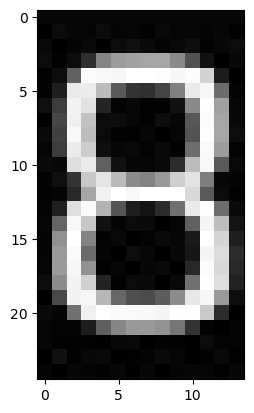

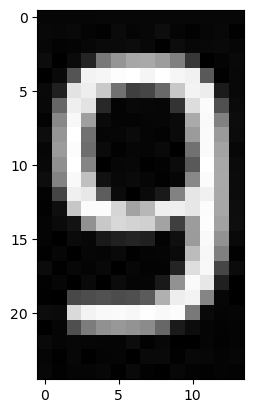

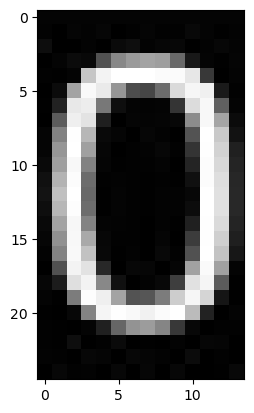

In [6]:
#preprocessing for stamps
stamp_paths = [
               r"C:\Osu!Conda\digits\one.jpg",
               r"C:\Osu!Conda\digits\two.jpg",
               r"C:\Osu!Conda\digits\three.jpg",
               r"C:\Osu!Conda\digits\four.jpg",
               r"C:\Osu!Conda\digits\five.jpg",
               r"C:\Osu!Conda\digits\six.jpg",
               r"C:\Osu!Conda\digits\seven.jpg",
               r"C:\Osu!Conda\digits\eight.jpg",
               r"C:\Osu!Conda\digits\nine.jpg",
               r"C:\Osu!Conda\digits\background.jpg"]

digit_stamps = ["dih"]
digit_stamps[0] = np.array((cv2.imread(r"C:\Osu!Conda\digits\zero.jpg", cv2.IMREAD_GRAYSCALE)))
for path in stamp_paths: 
    digit_stamps.append(np.array((cv2.imread(path, cv2.IMREAD_GRAYSCALE))))

start_row, end_row = 1000, 1080
start_col, end_col = 10, 60

digit_stamps[0] = digit_stamps[0][start_row:end_row, start_col+50:end_col+60]

for x in range(1,11):
    digit_stamps[x] = digit_stamps[x][start_row:end_row, start_col:end_col]
    print(digit_stamps[x].shape)

for digit in range(0,11):
    plt.imshow(digit_stamps[digit], cmap='gray')
    time.sleep(0.5)
    plt.show()

percent_stamp_paths = [
               r"C:\Osu!Conda\percent_digits\first_digit_stamp\blank.jpg",
               r"C:\Osu!Conda\percent_digits\first_digit_stamp\one.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\two.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\three.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\four.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\five.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\six.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\seven.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\eight.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\nine.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\zero.jpg"]

percent_stamps = []

for path in percent_stamp_paths: 
    percent_stamps.append(np.array((cv2.imread(path, cv2.IMREAD_GRAYSCALE))))

start_row2, end_row2 = 55, 80
start_col2, end_col2 = 1812, 1826
offset=17

percent_stamps[0] = percent_stamps[0][start_row2:end_row2, start_col2-offset:end_col2-offset]
percent_stamps[1] = percent_stamps[1][start_row2:end_row2, start_col2-offset-8:end_col2-offset-8]

plt.imshow(percent_stamps[0], cmap='gray')
time.sleep(0.05)
plt.show()
print(percent_stamps[0].shape)

plt.imshow(percent_stamps[1], cmap='gray')
time.sleep(0.05)
plt.show()
print(percent_stamps[1].shape)

for x in range(2, 11):
    percent_stamps[x] = percent_stamps[x][start_row2:end_row2, start_col2:end_col2]
    print(percent_stamps[x].shape)

for percent in range(2,11):
    plt.imshow(percent_stamps[percent], cmap='gray')
    time.sleep(0.05)
    plt.show()

In [7]:
#Screen Capture
def frame():
    with mss() as sct:
        osu_playfield = {"top": 0, "left": 240, "width": 1440, "height": 1080}

        # Get raw pixels from the screen, save it to a Numpy array, grayscale + resize
        
        osu_frame_gray_resized_np = cv2.resize(
            cv2.cvtColor(np.array(sct.grab(osu_playfield)), cv2.COLOR_BGRA2GRAY),
            (84,84),
            interpolation = cv2.INTER_AREA
        )
        # returns 1,84,84
        

        return osu_frame_gray_resized_np[np.newaxis, :, :]
    
#function for screen capturing the 2 retry areas
def retry_frame():
    with mss() as sct:
        retry_screen1_area = {"top":550,"left":920,"width":80,"height":25}
        retry_screen2_area = {"top":790+35,"left":1570,"width":100,"height":25}
        # Get raw pixels from the screen, save it to a Numpy array
        r1 = sct.grab(retry_screen1_area)
        r2 = sct.grab(retry_screen2_area)
        r_1_np = np.array(r1)
        r_2_np = np.array(r2)
        #convert to grayscale + resize
        retry_1_box = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        retry_2_box = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)

        retry_bounds = (retry_1_box,retry_2_box)
        return retry_bounds
    
#returns a tuple of the 4 combo digit areas
def digit_frames():
    with mss() as sct:
    
        # Get raw pixels from the screen, save it to a Numpy array

        r_1_np = np.array(sct.grab({"top":start_row,"left":start_col,"width":50,"height":80}))
        r_2_np = np.array(sct.grab({"top":start_row,"left":start_col+55,"width":55,"height":80}))
        r_3_np = np.array(sct.grab({"top":start_row,"left":start_col+110,"width":55,"height":80}))
        r_4_np = np.array(sct.grab({"top":start_row,"left":start_col+160,"width":55,"height":80}))
        #convert to grayscale + resize
        digits_box_1 = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        digits_box_2 = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)
        digits_box_3 = cv2.cvtColor(r_3_np, cv2.COLOR_BGR2GRAY)
        digits_box_4 = cv2.cvtColor(r_4_np, cv2.COLOR_BGR2GRAY)

        retry_bounds = (digits_box_1,digits_box_2,digits_box_3,digits_box_4)
        return retry_bounds
    


top = 55
left = 1810-3
width = 14
height = 25
off_set = 16
def percent_frames():
    with mss() as sct:
        
        # Get raw pixels from the screen, save it to a Numpy arra
        r_1_np = np.array(sct.grab({"top":top,"left":left-20,"width":width,"height":height}))
        r_2_np = np.array(sct.grab({"top":top,"left":left+off_set-11,"width":width,"height":height}))
        r_3_np = np.array(sct.grab({"top":top,"left":left+off_set*2-3,"width":width,"height":height}))
        r_4_np = np.array(sct.grab({"top":top,"left":left+off_set*3+6,"width":width,"height":height}))
        r_5_np = np.array(sct.grab({"top":top,"left":left+off_set*4+14,"width":width,"height":height}))

        #convert to grayscale + resize
        digits_box_1 = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        digits_box_2 = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)
        digits_box_3 = cv2.cvtColor(r_3_np, cv2.COLOR_BGR2GRAY)
        digits_box_4 = cv2.cvtColor(r_4_np, cv2.COLOR_BGR2GRAY)
        digits_box_5 = cv2.cvtColor(r_5_np, cv2.COLOR_BGR2GRAY)

        percent_bounds = (digits_box_1,digits_box_2,digits_box_3,digits_box_4,digits_box_5)
        return percent_bounds

In [9]:
time.sleep(8)
fraaame = frame()

In [ ]:
time.sleep(5)
retry_1, retry_2 = retry_frame()
plt.imshow(retry_1, cmap='gray')
plt.show()

In [ ]:
plt.imshow(retry_2, cmap='gray')
plt.show()


In [8]:
from pynput.mouse import Controller as MouseController, Button
from pynput.keyboard import Controller as KeyboardController
from pynput.keyboard import Key


In [9]:
# =========================

# CONSTANTS

# =========================
BACKGROUND_INDEX = 10
MIN_ACCEPT_SCORE = 0.80
MAX_FORWARD_JUMP = 25
MIN_MARGIN = 0.08

# Break handling

BREAK_LANDS_AT_OR_BELOW = 1
BREAK_CONFIRM_FRAMES = 2
BREAK_STRICT_CONF = 0.85

# Transition handling
ROLLOVER_TOLERANCE = 3
ROLLOVER_MAX_OVERSHOOT = 15

# NEW: anti-stuck / history + latch

HIST_LEN = 6
BREAK_LATCH_MS = 200               # Allow backwards updates briefly after break
BIG_DROP_RATIO = 0.7               # If RAW < 60% of STABLE, it's a break
BIG_DROP_MIN = 8                   # Or if RAW is 8 digits lower than STABLE
ALLOW_BACKWARDS_DURING_LATCH = True
APPEND_ZERO_REJECT = True          # Reject stable->stable*10 (9->90)
APPEND_ZERO_CONF_MIN = 0.75
ACCURACY_CONFIDENCE_THRESHOLD = 0.6

In [10]:
#Math Helpers for the Combo detector

def num_digits(n: int) -> int:
    return 1 if n == 0 else len(str(n))

def expected_rollover(prev: int) -> int:
    d = num_digits(prev)
    return 10 ** d

def is_plausible_rollover(prev: int, raw: int) -> bool:
    exp = expected_rollover(prev)
    if exp <= raw <= exp + ROLLOVER_TOLERANCE:
        return True
    if exp <= raw <= exp + ROLLOVER_MAX_OVERSHOOT:
        return True
    return False

In [ ]:
class OsuScreenEnv(gym.Env):
    def __init__(self, map_length=None):
        super().__init__()

        # =========================
        # SETTINGS 
        # =========================
        # Frame counter for tracking which frames to update cached combo digits
        self.frame_counter = 0
                
        
        # Track if cursor has been clamped to screen boundaries
        self.is_clipped = False
       
        # Combo tracking
        self.last_good_combo = 0  # Last validated combo value
        self.break_streak = 0  # Number of consecutive breaks detected
        self.raw_hist = []  # History of (raw_combo, confidence) tuples for break detection
        self.break_latch_until = 0.0  # Timestamp until which break latch is active

        # Accuracy tracking
        self.last_stable_val = 0.0  # Last stable accuracy value
        self.waiting_val = None  # Pending accuracy value waiting for confirmation
        self.total_frames_processed = 0  # Total frames for dynamic accuracy filtering

        # Circle detection for reward calculation
        # Stores previous frame's detected circles for distance-based rewards
        self.prev_circles = []
        self.current_circles = []  

        # Initialize the blob detector for finding circles on screen
        self._init_circle_detector()
        
        # Death detection stamps
        self.dead = False  # Flag indicating if player has failed
        
        # Load and prepare first retry screen detection stamp
        self.stamp_1_path = r"C:\Osu!Conda\images\Retry Screen 1 - Stamp.jpg"
        self.stamp_1 = cv2.imread(self.stamp_1_path)
        self.height1, self.width = self.stamp_1.shape[:2]
        self.half_height1 = self.height1 // 2 - 85
        # Crop to just the relevant part of the retry screen
        self.top_half = self.stamp_1[45:self.half_height1, 95:130]
        # Convert to grayscale for template matching
        self.stamp_gray_1 = cv2.cvtColor(self.top_half, cv2.COLOR_BGR2GRAY)

        # Load and prepare second retry screen detection stamp
        self.stamp_2_path = r"C:\Osu!Conda\images\Retry Screen 2 - Stamp.jpg"
        self.stamp_2 = cv2.imread(self.stamp_2_path)
        self.height2, self.width2 = self.stamp_2.shape[:2]
        self.half_height2 = self.height2 // 2 - 57
        # Crop to just the relevant part of the retry screen
        self.top_half2 = self.stamp_2[1:self.half_height2, :40]
        # Convert to grayscale for template matching
        self.stamp_gray_2 = cv2.cvtColor(self.top_half2, cv2.COLOR_BGR2GRAY)

        # Episode limits
        self.max_steps = map_length if map_length is not None else 1024  # Maximum steps before truncation
        self.step_count = 0  # Current step count in episode
        self.is_holding = False  # Track if mouse button is currently held

        # Controllers for mouse and keyboard input
        self.mouse = MouseController()
        self.keyboard = KeyboardController()

        # Frame stacking for temporal information
        # Agent sees last 4 frames to understand movement
        self.stack = 4
        self.frames = deque(maxlen=self.stack)

        # Timing
        self.prev_t = None  # Previous timestamp for calculating dt

        # Image dimensions (84x84 grayscale frames)
        self.h = 84
        self.w = 84

        # Scalar observation size (cursor x, cursor y, velocity x, velocity y, clipped flag, circle data)
        self.scalar_info_dimensions = 15

        # Observation space: stacked vision frames + scalar stats
        self.observation_space = spaces.Dict({
            "vision": spaces.Box(
                low=0,
                high=255,
                shape=(self.stack, self.h, self.w),
                dtype=np.uint8
            ),
            "stats": spaces.Box(
                low=-1.0,
                high=1.0,
                shape=(self.scalar_info_dimensions,),
                dtype=np.float32
            )
        })


        #action space for relax
        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        # Action space for standard: [dx, dy, hold]
        # dx, dy: mouse movement deltas in normalized -1 to 1 range
        # hold: mouse button state (>0 = press, <=0 = release)
        #self.action_space = spaces.Box(
            #low=np.array([-1.0, -1.0, -1.0], dtype=np.float32),
            #high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
            #dtype=np.float32
        #)

        # Cursor state tracking
        self.cursor_current_xy = np.array([0.0, 0.0])  # Current normalized position
        self.prev_cursor_xy = np.array([0.0, 0.0])  # Previous position for velocity
        self.vxy = np.array([0.0, 0.0])  # Normalized velocity

    def _init_circle_detector(self):
        """
        Initialize the blob detector for circle detection
        
        Sets up SimpleBlobDetector with parameters tuned for detecting
        osu! hit circles on 84x84 grayscale frames
        """
        # Create parameter object that will configure the detector
        params = cv2.SimpleBlobDetector_Params()
        
        # Enable area filtering - only detect blobs within size range
        params.filterByArea = True
        params.minArea = 35  # Minimum blob size in pixels (filters tiny noise)
        params.maxArea = 1000  # Maximum blob size in pixels (filters huge UI elements)
        
        # Disable shape filtering - we don't need perfect circles
        # This helps with overlapping circles and approach circles
        params.filterByCircularity = False
        params.filterByConvexity = False
        params.filterByInertia = False
        
        # Enable color filtering - only detect bright (white) blobs
        # This is crucial for finding the white hit circles
        params.filterByColor = True
        params.blobColor = 255  # Only detect white/bright pixels
        
        # Threshold settings control detection sensitivity
        params.minThreshold = 5  # Start detecting at brightness 5/255 (very permissive)
        params.maxThreshold = 255  # Go up to full white
        params.thresholdStep = 5  # Check every 5 brightness levels (more granular)
        
        # Create the actual detector object with our parameters
        self.blob_detector = cv2.SimpleBlobDetector_create(params)
    
    def detect_circles(self, frame_84x84):
        """
        Detects bright circles using SimpleBlobDetector
        Returns top 2 brightest circles sorted by brightness
        
        This method finds hit circles on the screen by detecting bright blobs
        and calculating their average brightness to prioritize the next circles to click
        
        Args:
            frame_84x84: numpy array of shape (84, 84) with uint8 values (grayscale frame)
        
        Returns:
            List of dicts: [{"x": 0.5, "y": 0.3, "brightness": 0.9, "radius": 25}, ...]
            - x, y are normalized 0-1 coordinates
            - brightness is average pixel value 0-1
            - radius is blob radius in pixels (on 84x84 frame)
            - List is sorted by brightness (brightest first)
            - Returns up to 2 circles (next and second-next)
        """
        # Run blob detection on the input frame
        # Returns a list of KeyPoint objects representing detected blobs
        keypoints = self.blob_detector.detect(frame_84x84)
        
        # Convert OpenCV keypoints to our custom format with brightness calculation
        circles = []
        for kp in keypoints:
            # Extract center position from keypoint (x, y in pixel coordinates)
            x, y = kp.pt
            # Convert to integers for array indexing
            x_int, y_int = int(x), int(y)
            
            # Calculate radius of the blob for brightness sampling
            # kp.size is the diameter, so divide by 2 to get radius
            radius = int(kp.size / 2)
            
            # Calculate bounding box around the blob for brightness sampling
            # Clamp to frame boundaries to avoid index errors
            y1, y2 = max(0, y_int - radius), min(84, y_int + radius)
            x1, x2 = max(0, x_int - radius), min(84, x_int + radius)
            
            # Calculate average brightness in the blob region
            # Higher brightness = circle is closer to being clickable (approach circle shrinking)
            # Normalize from 0-255 range to 0.0-1.0 range
            brightness = frame_84x84[y1:y2, x1:x2].mean() / 255.0
            
            # Store circle data with normalized coordinates (0-1 range)
            # This makes positions independent of screen resolution
            circles.append({
                "x": x / 84.0,  # Normalize x coordinate to 0-1
                "y": y / 84.0,  # Normalize y coordinate to 0-1
                "brightness": brightness,  # Already normalized 0-1
                "radius": radius  # Radius in pixels on 84x84 frame (for in-blob detection)
            })
        
        # Sort circles by brightness in descending order (brightest first)
        # The brightest circle is likely the next one to click
        circles.sort(key=lambda c: c["brightness"], reverse=True)
        
        # Return only the top 2 brightest circles
        # Circle 1 = next target, Circle 2 = upcoming target
        return circles[:2]

    # Core Gym Methods
    def step(self, action):
        """
        Execute one environment step
        
        Takes an action (mouse movement + click), updates game state,
        calculates reward, and returns new observation
        
        Args:
            action: [dx, dy, hold] - mouse movement and click state
        
        Returns:
            obs: Dictionary with 'vision' and 'stats'
            reward: Float reward value
            terminated: Boolean indicating if episode ended (death)
            truncated: Boolean indicating if episode hit max steps
            info: Dictionary with debugging info
        """
        # If player is dead, immediately return terminal state
        if self.dead:
            terminated = True
            truncated = False
            reward = 0.0
            # Return current observation without updating
            obs = {
                "vision": np.stack(list(self.frames), axis=0).astype(np.uint8),
                "stats": self.build_stats()
            }
            info = {"dead": True}
            return obs, reward, terminated, truncated, info
        
        # Save old values for reward calculation
        old_combo = self.last_good_combo
        old_acc = self.last_stable_val

        # Increment step counters
        self.step_count += 1
        self.frame_counter += 1
        
        # Check if we've hit max steps (for truncation)
        truncated = self.step_count >= self.max_steps
        
        # Calculate time delta for velocity calculation
        # Use 0.1s (10 FPS) as default for first frame
        now = time.time()
        dt = 0.1 if self.prev_t is None else max(1e-4, now - self.prev_t)
        self.prev_t = now
        
        # Apply the agent's action (move mouse, press/release button)
        self.apply_action(action)
        
        # Update cursor position and velocity based on actual mouse position
        self.update_cursor_state(dt)

        # Capture the current game frame (84x84 grayscale)
        frame_1chw = self.capture_frame()
        frame_hw = frame_1chw[0]

        # Detect circles on the current frame for reward calculation
        # This finds the bright hit circles and their positions
        current_circles = self.detect_circles(frame_hw)
        # Store circles in instance variable for build_stats() to access
        self.current_circles = current_circles

        # Read game state: combo count and accuracy percentage
        current_combo = self.read_combo_once()
        current_acc = self.read_accuracy_once(old_acc)

        # Add current frame to stack for temporal information
        self.frames.append(frame_hw)
        # Pad the stack if this is one of the first frames
        while len(self.frames) < self.stack:
            self.frames.append(frame_hw)
        # Stack frames into shape (4, 84, 84) for observation
        stacked_vision = np.stack(self.frames, axis=0).astype(np.uint8)

        # Build observation dictionary
        obs = {
            "vision": stacked_vision,  # 4 stacked grayscale frames
            "stats": self.build_stats()  # Cursor position, velocity, clipped flag, circle data
        }
        
        # Calculate reward using combo, accuracy, and circle proximity
        reward = self.get_reward(
            old_combo, current_combo, 
            old_acc, current_acc,
            current_circles  # Pass detected circles for proximity bonus
        )

        # Store current circles for potential future use (e.g., tracking movement)
        self.prev_circles = current_circles

        # Check for death/failure (retry screen detected)
        terminated = False
        truncated = False

        retry_frames_step = self.detect_death()
        if retry_frames_step["retry_screen_1"] == True or retry_frames_step["retry_screen_2"] == True:
            self.dead = True
            terminated = True
        elif self.step_count >= 1024:
            truncated = True 

        # Build info dictionary for debugging
        info = {
            "combo": current_combo,
            "acc": current_acc,
            "reward": reward,
            "step": self.step_count,
            "is_holding": self.is_holding,
            "delta_combo": current_combo - old_combo,
            "delta_acc": round(current_acc - old_acc, 4),
            "velocity x": self.vxy[0],
            "velocity y": self.vxy[1],            
        }

        return obs, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):
        
        """
        Reset the environment to start a new episode
        
        Hits retry button, resets all state variables, randomizes cursor position,
        and returns initial observation
        
        Args:
            seed: Random seed (optional)
            options: Additional options (optional)
        
        Returns:
            obs: Initial observation
            info: Empty info dict
        """
        super().reset(seed=seed)
        print("reset!")
        
        # Hit retry button in game to restart
        self.hit_retry()
        time.sleep(0.25)  # Wait for game to restart
        
        # Reset all tracking variables
        self.frame_counter = 0
        self.cached_digits = [BACKGROUND_INDEX, BACKGROUND_INDEX, BACKGROUND_INDEX, BACKGROUND_INDEX]
        self.cached_digit_confidences = [0.0, 0.0, 0.0, 0.0]
        self.waiting_val = None
        self.step_count = 0
        self.dead = False
        self.last_good_combo = 0
        self.last_stable_val = 0.0
        self.total_frames_processed = 0
        self.raw_hist.clear()
        self.break_latch_until = 0.0
        self.is_holding = False
        self.vxy = np.array([0.0, 0.0])
        self.waiting_val = None
        self.prev_circles = []  # Reset circle tracking
        self.current_circles = []  # Reset current circles

        
        # Reinitialize controllers to ensure clean state
        self.keyboard = KeyboardController()
        self.mouse = MouseController()

        # Reset digit update intervals in case they were modified
        self.digit_update_intervals = [1, 5, 50, 500]
        
        # Safety release of mouse button in case it was stuck
        try:
            self.mouse.release(Button.left)
        except Exception:
            pass
    
        # Reset timing
        self.prev_t = time.time()

        # Randomize cursor starting position within game area
        # Game area is x=240-1679, y=0-1079
        x = np.random.randint(241, 240 + 1439)
        y = np.random.randint(0, 1080)
        self.mouse.position = (x, y)
        self.is_clipped = False

        # Convert absolute position to relative position (remove offset)
        start_rel = np.array([x - 240, y], dtype=np.float32)
        self.prev_cursor_xy = start_rel
        # Normalize to 0-1 range for observation
        self.cursor_current_xy = start_rel / np.array([1440.0, 1080.0])
        self.vxy = np.array([0.0, 0.0])

        # Initialize frame stack with current frame repeated
        self.frames.clear()
        frame_1chw = self.capture_frame()
        frame_hw = frame_1chw[0]
        for _ in range(self.stack):
            self.frames.append(frame_hw)

        # Build initial observation
        obs = {
            "vision": np.stack(self.frames, axis=0).astype(np.uint8),
            "stats": self.build_stats()
        }

        return obs, {}
    
    # Helpers
    def read_accuracy_once(self, previous_accuracy_value):
        """
        Reads the 5-digit accuracy display (XX.XX%)
        
        Uses template matching to recognize each digit, applies confidence
        filtering and flicker detection to ensure stable readings
        
        Args:
            previous_accuracy_value: Last known good accuracy value
        
        Returns:
            Float accuracy value (0.0 to 100.0)
        """
        # Capture the 5 digit boxes from the accuracy display
        digit_box_crops = percent_frames() 
        detected_digits = []  # Will store digit values (0-9 or None)
        match_confidences = []  # Will store confidence for each detection

        # Template match each digit position
        for i, crop in enumerate(digit_box_crops):  
            best_match_index = -1
            highest_similarity_score = -1.0
            
            # Compare against all digit templates (0-9 + background)
            for stamp_index, stamp_image in enumerate(percent_stamps):
                # Template matching using normalized cross-correlation
                result_map = cv2.matchTemplate(crop, stamp_image, cv2.TM_CCOEFF_NORMED)
                _, max_similarity, _, _ = cv2.minMaxLoc(result_map)
                
                # Track highest similarity match
                if max_similarity > highest_similarity_score:
                    highest_similarity_score = max_similarity
                    best_match_index = stamp_index
            
            # Special case: 8 and 3 look similar, use scanline verification
            if best_match_index in [3, 8]:
                best_match_index = self._scanline_verify_8_vs_3(crop)
            
            # Handle special cases for background and leading zeros
            if best_match_index == 0: 
                detected_digits.append(None)  # Leading zero or decimal point
            elif best_match_index == 10: 
                detected_digits.append(0)  # Zero digit
            else: 
                detected_digits.append(best_match_index)  # Regular digit 1-9
            
            match_confidences.append(highest_similarity_score)

        # Convert detected digits to accuracy value
        try:
            # Extract each digit position (XX.XX format)
            hundreds_val = detected_digits[0] if detected_digits[0] is not None else 0
            tens_val = detected_digits[1] if detected_digits[1] is not None else 0
            ones_val = detected_digits[2] if detected_digits[2] is not None else 0
            tenths_val = detected_digits[3] if detected_digits[3] is not None else 0
            hundredths_val = detected_digits[4] if detected_digits[4] is not None else 0
            
            # Calculate accuracy as float (e.g., 98.76)
            calculated_accuracy = (
                (hundreds_val * 100) + (tens_val * 10) + (ones_val * 1) + 
                (tenths_val * 0.1) + (hundredths_val * 0.01)
            )
            
            # Average confidence across all 5 digits
            average_match_confidence = sum(match_confidences) / 5
        except Exception as error:
            # If calculation fails, return previous value
            return previous_accuracy_value

        # Filter 1: Reject if confidence too low
        if average_match_confidence < ACCURACY_CONFIDENCE_THRESHOLD:
            return previous_accuracy_value 

        # Filter 2: Clamp to valid range
        if calculated_accuracy > 100.0:
            calculated_accuracy = 100.0

        # Update total frames for dynamic filtering
        self.total_frames_processed += 1

        # Calculate dynamic trust threshold (more lenient early, stricter later)
        if self.total_frames_processed < 251:
            trust_threshold = 100  # Very lenient during early game
        elif self.total_frames_processed < 700:
            # Gradually tightens as game progresses
            trust_threshold = 100 * ((250 / self.total_frames_processed)) ** 2.5
        else:
            trust_threshold = 5  # Very strict after 700 frames

        # Flicker detection: reject sudden large changes unless confirmed
        diff = abs(calculated_accuracy - self.last_stable_val)

        if diff > trust_threshold:
            # Large change detected
            if self.waiting_val is not None and abs(calculated_accuracy - self.waiting_val) < 0.05:
                # This is the 2nd frame showing this change - it's real, accept it
                self.last_stable_val = calculated_accuracy
                self.waiting_val = None
            else:
                # First frame showing this change - put in waiting room
                self.waiting_val = calculated_accuracy
                return previous_accuracy_value
        else:
            # Small change - accept immediately
            self.last_stable_val = calculated_accuracy
            self.waiting_val = None

        return self.last_stable_val
    
    def read_combo_once(self):
        """
        Reads the combo counter from screen
        
        Uses template matching on up to 4 digit positions (ones, tens, hundreds, thousands).
        Applies confidence filtering and break detection to handle misses/combo breaks.
        
        Returns:
            Integer combo value (stable, filtered)
        """
        # Capture the 4 digit boxes from the combo display
        digits = digit_frames()
        recognized_digits = []  # Valid digits found (0-9)
        digit_scores = []  # Confidence scores for each digit

        # Template match each digit position (right to left: ones, tens, hundreds, thousands)
        for x in range(4):
            best_match_index = None
            best_match_score = -1.0
            second_best_score = -1.0

            # Compare against all digit templates (0-9 + background)
            for y in range(11):
                # Template matching using normalized cross-correlation
                similarity_map = cv2.matchTemplate(digits[x], digit_stamps[y], cv2.TM_CCOEFF_NORMED)
                _, max_val, _, _ = cv2.minMaxLoc(similarity_map)
                
                # Track best and second-best matches for margin calculation
                if max_val > best_match_score:
                    second_best_score = best_match_score
                    best_match_score = float(max_val)
                    best_match_index = y
                elif max_val > second_best_score:
                    second_best_score = float(max_val)

            # Calculate margin between best and second-best match
            match_margin = best_match_score - second_best_score
            
            # If margin too small and not background, confidence is low - reject all
            if best_match_index != BACKGROUND_INDEX and match_margin < MIN_MARGIN:
                recognized_digits = []
                break
            
            # If we hit background, no more digits to the left - stop
            if best_match_index == BACKGROUND_INDEX:
                break
            
            # Valid digit found - add to list
            recognized_digits.append(best_match_index)
            digit_scores.append(best_match_score)

        # Build raw combo value and confidence
        if not recognized_digits:
            # No valid digits detected
            raw_combo = 0
            confidence = 0.0
        else:
            # Convert digit list to integer (e.g., [1, 2, 3] -> 123)
            raw_combo = int("".join(str(d) for d in recognized_digits))
            # Overall confidence is the weakest link (minimum score)
            confidence = float(min(digit_scores))

        # Special case: reject all-zeros (e.g., "00" is probably a misread)
        if len(recognized_digits) >= 2 and all(d == 0 for d in recognized_digits):
            confidence = 0.0

        # Add to history for break detection
        self._push_hist(raw_combo, confidence)

        # Filter raw value into stable combo using break detection logic
        stable_combo = self.last_good_combo  # Default: keep last known good value
        accepted = False  # Will we accept this new reading?
        now = time.time()
        in_latch = now < self.break_latch_until  # Are we in break grace period?

        # Only consider readings with sufficient confidence
        if confidence < MIN_ACCEPT_SCORE:
            pass  # Low confidence - keep last value
        else:
            # Check for appended zero glitch (e.g., 9 -> 90)
            if (APPEND_ZERO_REJECT and confidence >= APPEND_ZERO_CONF_MIN and 
                self.last_good_combo >= 1 and raw_combo == self.last_good_combo * 10):
                pass  # Reject appended zero
            
            # Same value - accept
            elif raw_combo == self.last_good_combo:
                accepted = True
            
            # Forward movement (combo increased)
            elif raw_combo > self.last_good_combo:
                jump = raw_combo - self.last_good_combo
                
                # Small jump - accept
                if jump <= MAX_FORWARD_JUMP:
                    stable_combo = raw_combo
                    accepted = True
                # Large jump - check if it's a valid rollover (9->10, 99->100)
                elif is_plausible_rollover(self.last_good_combo, raw_combo):
                    stable_combo = raw_combo
                    accepted = True
            
            # Backwards movement (potential combo break)
            else:
                # During break latch period, accept backwards movement immediately
                if ALLOW_BACKWARDS_DURING_LATCH and in_latch:
                    stable_combo = raw_combo
                    accepted = True
                else:
                    # Check history for multiple frames confirming the break
                    tiny_cnt, bigdrop_cnt = self._count_break_like(self.last_good_combo)
                    break_confirmed = (tiny_cnt >= BREAK_CONFIRM_FRAMES) or (bigdrop_cnt >= BREAK_CONFIRM_FRAMES)

                    if break_confirmed:
                        # Multiple frames confirm break - accept it
                        stable_combo = raw_combo
                        accepted = True
                        # Enter break latch period (more lenient for next few frames)
                        self.break_latch_until = now + (BREAK_LATCH_MS / 1000.0)
                    # Special case: instant reset to 0 with very high confidence
                    elif (raw_combo <= BREAK_LANDS_AT_OR_BELOW and 
                        self.last_good_combo > BREAK_LANDS_AT_OR_BELOW and 
                        confidence >= 0.95):
                        stable_combo = raw_combo
                        accepted = True
                        self.break_latch_until = now + (BREAK_LATCH_MS / 1000.0)

        # Update last good combo if we accepted the new value
        if accepted:
            self.last_good_combo = stable_combo

        return stable_combo
    
    def apply_action(self, action):
        """
        Apply agent's action to the game
        
        Moves mouse and presses/releases button based on action values
        
        Args:
            action: [dx, dy, hold]
                dx, dy: Mouse movement deltas in -1 to 1 range
                hold: Button state (>0 = press, <=0 = release)
        """

        #unpack relax actions
        dx, dy = action
        # Unpack action
        #dx, dy, hold = action

        # Scale movement from -1..1 range to pixels
        max_pixels = 200  # Maximum pixels to move in one step
        self.mouse.move(int(dx * max_pixels), int(dy * max_pixels))

        # Determine desired button state
        '''want_hold = (hold > 0)
        
        # State-based press/release to avoid spamming
        if want_hold and not self.is_holding:
            # Want to hold but not currently holding - press button
            self.mouse.press(Button.left)
            self.is_holding = True
        elif (not want_hold) and self.is_holding:
            # Want to release and currently holding - release button
            self.mouse.release(Button.left)
            self.is_holding = False'''

    def _push_hist(self, raw, conf):
        """
        Add a combo reading to the history buffer
        
        Used for break detection - tracks recent combo values and confidences
        
        Args:
            raw: Raw combo value read from screen
            conf: Confidence score for this reading
        """
        # Append (combo, confidence) tuple to history
        self.raw_hist.append((raw, conf))
        
        # Maintain fixed history length by removing oldest entry
        if len(self.raw_hist) > HIST_LEN:
            self.raw_hist.pop(0)

    def _count_break_like(self, stable_now: int):
        """
        Count recent history entries that look like combo breaks
        
        Looks for two types of breaks:
        1. "Tiny" breaks: Combo dropped to 0-3
        2. "Big drop" breaks: Combo dropped significantly
        
        Args:
            stable_now: Current stable combo value
        
        Returns:
            (tiny_count, bigdrop_count): Number of each break type in history
        """
        tiny = 0  # Count of breaks to 0-3
        bigdrop = 0  # Count of significant drops
        
        # Iterate through recent history
        for r, c in self.raw_hist:
            # Only consider high-confidence readings
            if c >= BREAK_STRICT_CONF:
                # Check if this looks like a break to near-zero
                if r <= BREAK_LANDS_AT_OR_BELOW:
                    tiny += 1
                
                # Check if this looks like a significant drop from current combo
                if stable_now > r:
                    # Determine if drop is significant
                    is_significant = (
                        (stable_now - r >= BIG_DROP_MIN) or  # Dropped by at least X
                        (r <= stable_now * BIG_DROP_RATIO) or  # Dropped to less than X% of original
                        (stable_now < 10 and r < stable_now)  # Any drop when combo is small
                    )
                    if is_significant:
                        bigdrop += 1
        
        return tiny, bigdrop

    def capture_frame(self):
        """
        Capture the current game frame from screen
        
        Returns:
            Frame in shape (1, 84, 84) - grayscale
        """
        return frame()

    def update_cursor_state(self, dt):
        """
        Update cursor position, velocity, and clipping state
        
        Reads actual mouse position, clamps to game area, calculates velocity
        
        Args:
            dt: Time delta since last update (seconds)
        """
        # Get current physical mouse position (absolute screen coordinates)
        abs_x, abs_y = self.mouse.position
        
        # Clamp cursor to game area (x: 240-1679, y: 0-1079)
        # This prevents the agent from moving outside the visible game area
        clamped_x = np.clip(abs_x, 240, 240 + 1439)
        clamped_y = np.clip(abs_y, 0, 1079)
        
        # If cursor was outside bounds, teleport it back
        if abs_x != clamped_x or abs_y != clamped_y:
            self.mouse.position = (clamped_x, clamped_y)
            abs_x, abs_y = clamped_x, clamped_y
            self.is_clipped = True  # Flag that we hit the boundary
        else:
            self.is_clipped = False
        
        # Convert to relative coordinates (remove game area offset)
        rel_xy = np.array([abs_x - 240, abs_y], dtype=np.float32)

        # Calculate velocity (pixels per second)
        raw_v = (rel_xy - self.prev_cursor_xy) / dt
        
        # Normalize velocity to -1..1 range and clip
        # Divide by 3500 to scale typical velocities to -1..1
        self.vxy = np.clip(raw_v / 3500.0, -1.0, 1.0)
        
        # Normalize cursor position to 0..1 range for observation
        self.cursor_current_xy = rel_xy / np.array([1440.0, 1080.0])
        
        # Store current position for next frame's velocity calculation
        self.prev_cursor_xy = rel_xy

    def build_stats(self):
        """
        Build scalar observation including circle positions
    
        Returns array of shape (15,):
        [0-1]: cursor position (x, y)
        [2-3]: cursor velocity (vx, vy)
        [4]: clipped flag
        [5-7]: circle 1 (x, y, brightness)
        [8-9]: relative distance to circle 1 (dx, dy)
        [10-12]: circle 2 (x, y, brightness)
        [13-14]: relative distance to circle 2 (dx, dy)
        """
        # Base cursor stats (5 values)
        stats = [
            self.cursor_current_xy[0],  # Cursor X position (0-1)
            self.cursor_current_xy[1],  # Cursor Y position (0-1)
            self.vxy[0],  # Cursor X velocity (-1 to 1)
            self.vxy[1],  # Cursor Y velocity (-1 to 1)
            1.0 if self.is_clipped else 0.0  # Clipping flag (0 or 1)
        ]

        # Circle 1 info (5 values: x, y, brightness, dx, dy)
        if len(self.current_circles) > 0:
            circle1 = self.current_circles[0]
            stats.extend([
                circle1["x"],           # X position (0-1)
                circle1["y"],           # Y position (0-1)
                circle1['brightness'],  # Brightness (0-1)
            ])
            # Relative distance to circle 1 (directional vector)
            dx = circle1["x"] - self.cursor_current_xy[0]
            dy = circle1["y"] - self.cursor_current_xy[1]
            stats.extend([dx, dy])
        else:
            # No circle 1 detected - fill with zeros
            stats.extend([0.0, 0.0, 0.0, 0.0, 0.0])

        # Circle 2 info (5 values: x, y, brightness, dx, dy)
        if len(self.current_circles) > 1:
            circle2 = self.current_circles[1]
            stats.extend([
                circle2["x"],           # X position (0-1)
                circle2["y"],           # Y position (0-1)
                circle2['brightness'],  # Brightness (0-1)
            ])
            # Relative distance to circle 2 (directional vector)
            dx = circle2["x"] - self.cursor_current_xy[0]
            dy = circle2["y"] - self.cursor_current_xy[1]
            stats.extend([dx, dy])
        else:
            # No circle 2 detected - fill with zeros
            stats.extend([0.0, 0.0, 0.0, 0.0, 0.0])

        # Total: 5 (base) + 5 (circle1) + 5 (circle2) = 15 values
        return np.array(stats, dtype=np.float32)

    def get_reward(self, old_combo, current_combo, old_acc, current_acc, current_circles):
        """
        Calculate reward for the current step
        
        Reward components:
        1. Combo increase: +1.0
        2. Accuracy improvement: +0.1
        3. Cursor clipping: -0.5
        4. Circle proximity bonus: up to +0.1 (circle 1), +0.05 (circle 2)
        5. In-blob bonus: +0.125 when cursor is inside circle 1's detected radius (NEW!)
        
        Args:
            old_combo: Combo value from previous step
            current_combo: Combo value from current step
            old_acc: Accuracy from previous step
            current_acc: Accuracy from current step
            current_circles: List of detected circles [{"x", "y", "brightness", "radius"}, ...]
        
        Returns:
            Float reward value
        """
        reward = 0.0
    
        # 1. Combo Increase - hit a circle successfully
        if current_combo > old_combo:
            reward += 2.0

        # 2. Accuracy improvement - playing well
        if current_acc > old_acc:
            reward += 0.25

        #if current_acc < old_acc:
            #reward -= 0.5


        # 3. Punish cursor clipping - trying to leave play area
        if self.is_clipped:
            reward -= 0.5

        # 4. Circle proximity and in-blob bonuses
        if len(current_circles) > 0:
            # Get current cursor position (already normalized 0-1)
            cursor_x = self.cursor_current_xy[0]
            cursor_y = self.cursor_current_xy[1]
            
            # Circle 1 (brightest/next circle to click)
            circle1 = current_circles[0]
            
            # Calculate distance in pixels on 84x84 frame (more accurate)
            cursor_x_px = cursor_x * 84.0
            cursor_y_px = cursor_y * 84.0
            circle1_x_px = circle1["x"] * 84.0
            circle1_y_px = circle1["y"] * 84.0
            
            # Euclidean distance in pixels
            distance1_px = np.sqrt(
                (cursor_x_px - circle1_x_px)**2 + 
                (cursor_y_px - circle1_y_px)**2
            )
            
            # IN-BLOB BONUS (NEW!)
            # Check if cursor is inside the detected blob's radius
            # circle1["radius"] is already in pixels on the 84x84 frame
            circle_radius_px = circle1["radius"]
            
            if distance1_px <= circle_radius_px:
                # Cursor is inside the circle's hitbox!
                # Binary bonus for being inside
                # reduced from 0.3 to help with tracking sliders
                reward += 0.2
            
            # PROXIMITY BONUS (for moving toward circle)
            # Calculate normalized distance for proximity gradient
            distance1_norm = np.sqrt(
                (cursor_x - circle1["x"])**2 + 
                (cursor_y - circle1["y"])**2
            )
            max_distance_norm = np.sqrt(2)  # ~1.414 (corner to corner)
            
            # Proximity bonus: up to +0.1 based on distance
            # Guides agent toward circle when outside
            proximity_bonus1 = max(0, 0.1 * (1.0 - distance1_norm / max_distance_norm))
            reward += proximity_bonus1
            
            # Circle 2 (2nd brightest/upcoming circle): proximity only
            if len(current_circles) > 1:
                circle2 = current_circles[1]
                distance2_norm = np.sqrt(
                    (cursor_x - circle2["x"])**2 + 
                    (cursor_y - circle2["y"])**2
                )
                # Smaller proximity bonus for second circle
                proximity_bonus2 = max(0, 0.05 * (1.0 - distance2_norm / max_distance_norm))
                reward += proximity_bonus2
            
        return reward

    def hit_retry(self):
        """
        Press the retry key to restart the map
        
        Uses keyboard press of '1' key which is bound to retry in osu!
        """
        if self.step_count >= 1024:
            # Press and release '1' key to retry
            self.keyboard.press('1')
            time.sleep(0.35)  # Hold for 350ms
            self.keyboard.release('1')
            
    def close(self):
        """
        Clean up resources when environment is closed
        """
        cv2.destroyAllWindows()

    def retry_frames(self):
        """
        Capture frames for retry screen detection
        
        Returns:
            Tuple of (retry_frame_1, retry_frame_2) for template matching
        """
        return retry_frame()
    
    def _scanline_verify_8_vs_3(self, crop):
        """
        Distinguish between digit 8 and digit 3 using scanline analysis
        
        8 and 3 look very similar in template matching, but differ in structure:
        - An '8' has a closed loop at the top with left and right walls
        - A '3' only has a right wall at the top
        
        This method checks horizontal scanlines to count wall crossings
        
        Args:
            crop: Small grayscale image crop of the digit
        
        Returns:
            8 or 3 depending on detected structure
        """
        def count_crossings(y_level):
            """
            Count how many times we enter/exit bright regions on a horizontal line
            
            An '8' enters twice (left wall, then right wall)
            A '3' enters once (only right wall)
            """
            crossings = 0
            in_white = False
            
            # Scan horizontally across the digit
            for x in range(14):
                # Threshold at 150 for bright osu! text
                is_bright = crop[y_level, x] > 150
                
                # Entering a bright region
                if is_bright and not in_white:
                    crossings += 1
                    in_white = True
                # Leaving a bright region
                elif not is_bright and in_white:
                    in_white = False
            
            return crossings

        # Check multiple scanlines near the top of the digit for robustness
        # Take the maximum crossing count found across these lines
        top_pulses = max(count_crossings(y) for y in [5, 6, 7])
    
        # If we see 2 crossing points, it's an '8' (has both walls)
        # If we see 1 crossing point, it's a '3' (only right wall)
        return 8 if top_pulses >= 2 else 3

    def detect_death(self):
        """
        Detect if the retry screen is showing (player failed)
        
        Uses template matching to check for two different retry screen layouts
        
        Returns:
            Dictionary: {"retry_screen_1": bool, "retry_screen_2": bool}
        """
        # Capture current retry screen regions
        self.retry_1_frame, self.retry_2_frame = self.retry_frames()
        
        # Initialize result
        detected_retry = {"retry_screen_1": False, "retry_screen_2": False}

        # Check first retry screen template
        similarity_map_1 = cv2.matchTemplate(
            self.retry_1_frame, 
            self.stamp_gray_1, 
            cv2.TM_CCOEFF_NORMED
        )
        _, max_val_1, _, _ = cv2.minMaxLoc(similarity_map_1)

        # Check second retry screen template
        similarity_map_2 = cv2.matchTemplate(
            self.retry_2_frame, 
            self.stamp_gray_2, 
            cv2.TM_CCOEFF_NORMED
        )
        _, max_val_2, _, _ = cv2.minMaxLoc(similarity_map_2)

        # High similarity threshold indicates retry screen is present
        if max_val_1 > 0.8:
            detected_retry["retry_screen_1"] = True
            return detected_retry
        elif max_val_2 > 0.7:
            detected_retry["retry_screen_2"] = True
            return detected_retry
        
        return detected_retry

In [14]:
env = OsuScreenEnv()
obs, info = env.reset()
print(type(obs), obs.keys())
print(obs["vision"].shape, obs["vision"].dtype)
print(obs["stats"].shape, obs["stats"].dtype)


reset!
<class 'dict'> dict_keys(['vision', 'stats'])
(4, 84, 84) uint8
(15,) float32


In [12]:
# Import os for file path management
import os 
# Import Base Callback for saving models
from stable_baselines3.common.callbacks import BaseCallback
# Check Environment    
from stable_baselines3.common import env_checker
import os
import time
from stable_baselines3 import PPO



In [16]:
time.sleep(1)
env_checker.check_env(env)

reset!
reset!
reset!


In [13]:

class TrainAndLoggingCallback(BaseCallback):
    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _on_step(self) -> bool:
        # grab the info dict from the environment
        

        # Handle periodic saving
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, f'best_model_{self.n_calls}')
            self.model.save(model_path)
            info = self.locals['infos'][0]
            result_formatted = ", ".join(f"{key}: {value}" for key, value in info.items())
            print(result_formatted, flush=True)
            
        return True

In [14]:
CHECKPOINT_DIR = './train/'
LOG_DIR = './logs/'

In [15]:
# --- CONFIGURATION ---
MODEL_PATH = "osu_ppo_bot_v1.zip"
LOG_DIR = "./logs/"
CHECKPOINT_DIR = "./train/"
MAP_STEPS = 160000

# 1. Initializenvironment
# (Ensure your OsuScreenEnv class is defined in this file or imported)
env = OsuScreenEnv()

# 2. Setup the Callback (Your insurance policy)
callback = TrainAndLoggingCallback(check_freq=8192, save_path=CHECKPOINT_DIR)

# 3. Load or Create the Model
if os.path.exists(MODEL_PATH):
    print(f"\n[SYSTEM] Loading existing model from {MODEL_PATH}...")
    # env=env ensures the loaded model connects to your current screen capture
    model = PPO.load(MODEL_PATH, env=env, tensorboard_log=LOG_DIR)
else:
    print("\n[SYSTEM] No model found. Initializing a new PPO brain...")
    model = PPO(
        "MultiInputPolicy",
        env,
        verbose=1,
        learning_rate=1e-3,
        n_steps=4096,
        n_epochs=4,
        batch_size=1024,
        ent_coef=0.01, 
        clip_range=0.3,
        gamma=0.95,
        tensorboard_log=LOG_DIR
    )

# 4. Manual Map-by-Map Loop
try:
    while True:
        print("\n" + "="*50, flush=True)
        print(f" TOTAL STEPS TRAINED: {model.num_timesteps}", flush=True)
        print("="*50, flush=True)
        print("ACTION REQUIRED:", flush=True)
        print(" 1. Load a map in Osu!", flush=True)
        print(" 2. Get to the starting screen.", flush=True)

        print("\n[TRAINING] Bot is now active. Switching focus to Osu!...")
        time.sleep(10) # Brief window to click back into the game

        # reset_num_timesteps=False is the key to resuming progress
        model.learn(
            total_timesteps=MAP_STEPS, 
            callback=callback, 
            reset_num_timesteps=False
        )

        # Save progress immediately after the map ends
        model.save(MODEL_PATH)
        print(f"\n[SAVE] Progress synced to {MODEL_PATH}")

        # Pause and ask for next map
        choice = input("\nMap finished. Train another map? (y/n): ")
        if choice.lower() != 'y':
            print("[EXIT] Ending session.")
            break

except KeyboardInterrupt:
    print("\n[INTERRUPTED] Manual stop detected. Saving latest progress...")
    model.save(MODEL_PATH)

finally:
    env.close()
    print("[CLOSED] Environment shut down safely.")


[SYSTEM] Loading existing model from osu_ppo_bot_v1.zip...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

 TOTAL STEPS TRAINED: 421888
ACTION REQUIRED:
 1. Load a map in Osu!
 2. Get to the starting screen.

[TRAINING] Bot is now active. Switching focus to Osu!...
reset!
Logging to ./logs/PPO_0
reset!
reset!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 52.1     |
|    ep_rew_mean     | 38.9     |
| time/              |          |
|    fps             | 9        |
|    iterations      | 1        |
|    time_elapsed    | 206      |
|    total_timesteps | 423936   |
---------------------------------
reset!
reset!
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 72.6      |
|    ep_rew_mean          | 52.7      |
| time/                   |           |
|    fps                  | 9         |
|    iterations           | 2         |
|    time_elapsed       

In [ ]:
%pip install tensorflow


In [16]:
# 1. Create the environment (must match the one used in training)
env = OsuScreenEnv()

# 2. Load the trained model from the zip file
model = PPO.load("osu_ppo_bot_v1", env=env)
time.sleep(10)
# 3. Run the model
obs, info = env.reset()
for _ in range(512):
    action, _states = model.predict(obs, deterministic=False)
    obs, reward, terminated, truncated, info = env.step(action)
    
    # Render is handled by the gym.make(render_mode="human")
    
    if terminated or truncated:
        obs, info = env.reset()

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
reset!


In [40]:
model = PPO.load("osu_ppo_bot_v1.zip", env=env)

# Print the full architecture
print("\n=== MODEL ARCHITECTURE ===")
print(model.policy)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

=== MODEL ARCHITECTURE ===
MultiInputActorCriticPolicy(
  (features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (stats): Flatten(start_dim=1, end_dim=-1)
      (vision): NatureCNN(
        (cnn): Sequential(
          (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
          (1): ReLU()
          (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
          (3): ReLU()
          (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
          (5): ReLU()
          (6): Flatten(start_dim=1, end_dim=-1)
        )
        (linear): Sequential(
          (0): Linear(in_features=3136, out_features=256, bias=True)
          (1): ReLU()
        )
      )
    )
  )
  (pi_features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (stats): Flatten(start_dim=1, end_dim=-1)
      (vision): NatureCNN(
        (cnn): Sequential(
          (0): Conv2d(4, 32, kernel_size=(8, 8

In [42]:
# Get observation from environment
obs, _ = env.reset()

print("\n=== OBSERVATION STRUCTURE ===")
print(f"Vision shape: {obs['vision'].shape}")  # Should be (4, 84, 84)
print(f"Stats shape: {obs['stats'].shape}")    # Should be (15,)

# Pass through feature extractor
import torch

# Convert to torch tensors
device = model.policy.device  # Get model's device (cuda or cpu)

vision_tensor = torch.as_tensor(obs['vision']).unsqueeze(0).float().to(device)
stats_tensor = torch.as_tensor(obs['stats']).unsqueeze(0).float().to(device)

obs_dict = {
    'vision': vision_tensor,
    'stats': stats_tensor
}

# Extract features
with torch.no_grad():
    features = model.policy.features_extractor(obs_dict)
    
print(f"\nExtracted features shape: {features.shape}")
# Should be something like (1, 527) = 512 from CNN + 15 from stats

# Verify CNN contribution
print(f"Expected: 512 (CNN) + 15 (stats) = 527 total")

reset!

=== OBSERVATION STRUCTURE ===
Vision shape: (4, 84, 84)
Stats shape: (15,)

Extracted features shape: torch.Size([1, 271])
Expected: 512 (CNN) + 15 (stats) = 527 total
